# EBSD interoperability

This tutorial covers the end-to-end EBSD–APD workflow using the Tata Steel low-carbon steel dataset.

1. **Load and plot a `.ang` file** — raw pixel-level Euler-angle map, no MTEX required
2. **Grain finding with MTEX** — `MTEXEngine.find_grains` and `export_grain_metadata` *(MATLAB + MTEX required)*
3. **Load MTEX grain output** and plot the grain-level IPF map
4. **Fit an APD** using the MTEX grain geometry
5. **Export back to `.ang`** via `write_ang_file`
6. **`.h5oina` import** (Oxford Instruments HDF5 format) — brief note

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from numpy.polynomial import Legendre

import PyAPD
from PyAPD.ebsd_utils import write_ang_file
from PyAPD.mtex_interface import MTEXEngine
from PyAPD.log_res import min_diagram_system

DATA_DIR = Path("../../data/2D_Tata_Steel_paper_example")

[KeOps] Warning : CUDA libraries not found or could not be loaded; Switching to CPU only.


---
## 1. Load and plot a `.ang` file

A TSL/OIM `.ang` file stores per-pixel Euler angles, quality metrics, and phase information.
We parse it with a small helper, then visualise a raw Euler-angle RGB map — no MTEX needed.

In [2]:
def load_ang(path):
    """Parse a TSL .ang file. Returns header dict and data array."""
    meta, rows = {}, []
    with open(path) as f:
        for line in f:
            if line.startswith('#'):
                for key in ['XSTEP', 'YSTEP', 'NCOLS_ODD', 'NCOLS_EVEN', 'NROWS']:
                    if f'# {key}:' in line:
                        meta[key] = float(line.split(':')[1])
            else:
                rows.append(line.split())
    data = np.array(rows, dtype=np.float32)
    return meta, data
    # Columns: phi1 Phi phi2  x  y  IQ  CI  Phase  SEM  Fit

meta, ang = load_ang(DATA_DIR / 'sample_lc_steel.ang')
print(f"Grid: {int(meta['NCOLS_ODD'])}\u00d7{int(meta['NROWS'])} pixels, "
      f"step {meta['XSTEP']:.3f} \u00d7 {meta['YSTEP']:.3f} \u03bcm")
print(f"Total pixels loaded: {len(ang):,}")

Grid: 901×1154 pixels, step 1.000 × 0.866 μm
Total pixels loaded: 1,039,177


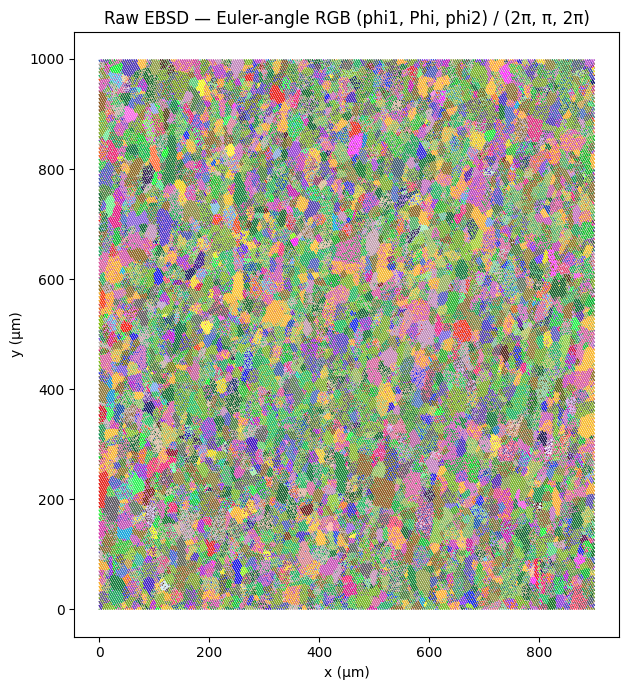

In [3]:
# Euler-angle RGB map: phi1 \u2192 R, Phi \u2192 G, phi2 \u2192 B  (normalised to [0, 1])
# Subsample every 4th pixel so the scatter is quick to render
idx = np.arange(0, len(ang), 4)
xy  = ang[idx, 3:5]  # x, y in \u03bcm
rgb = np.column_stack([
    ang[idx, 0] / (2 * np.pi),  # phi1
    ang[idx, 1] / np.pi,         # Phi
    ang[idx, 2] / (2 * np.pi),  # phi2
]).clip(0, 1)

fig, ax = plt.subplots(figsize=(8, 7))
ax.scatter(xy[:, 0], xy[:, 1], c=rgb, s=0.9, linewidths=0, rasterized=True)
ax.set_aspect('equal')
ax.set_xlabel('x (\u03bcm)'); ax.set_ylabel('y (\u03bcm)')
ax.set_title('Raw EBSD \u2014 Euler-angle RGB (phi1, Phi, phi2) / (2\u03c0, \u03c0, 2\u03c0)')
plt.tight_layout()
plt.show()

The map shows orientation variation at the pixel level. Grain structure is visible as smoothly coloured patches, but individual grains are not yet segmented.

---
## 2. Grain finding with MTEX

> **Requirements:** MATLAB (R2025b), MTEX (\u2265 6.1), `matlabengine` (`pip install PyAPD[mtex]`).
> Set the `MTEX_PATH` environment variable to your MTEX installation directory.

`MTEXEngine.find_grains` loads the `.ang` file into MTEX, runs two passes of grain finding
(removing small grains between passes), and stores results in the MATLAB workspace.
`export_grain_metadata` then writes three files and returns their paths:
- `grain_map.txt` \u2014 (x, y, grainId) per indexed pixel
- `grains_mean_orientation.txt` \u2014 (phi1, Phi, phi2) per grain (radians)
- `grains_coloring.txt` \u2014 IPF-Z RGB colour per grain

In [4]:
mtex_out_dir = '/tmp/pyapd_ebsd_tutorial'

with MTEXEngine() as eng:
    info = eng.find_grains(
        str(DATA_DIR / 'sample_lc_steel.ang'),
        misorientation_threshold=1.0,
        min_pixels=10,
    )
    print(f"MTEX found {info['n_grains']} grains in {info['n_pixels']} indexed pixels")
    paths = eng.export_grain_metadata(mtex_out_dir)

# Load outputs
gm          = np.loadtxt(paths['grain_map'],        skiprows=1)  # (M, 3): x, y, grainId
mean_orient = np.loadtxt(paths['mean_orientation'],  skiprows=1)  # (N, 3): phi1, Phi, phi2
coloring    = np.loadtxt(paths['coloring'],          skiprows=1)  # (N, 3): IPF-Z RGB

Y_um_mtex  = torch.tensor(gm[:, :2], dtype=torch.float32)
grain_ids  = torch.tensor(gm[:, 2],  dtype=torch.int32) - 1  # 1-indexed \u2192 0-indexed
N_grains   = int(grain_ids.max()) + 1

print(f"{N_grains} grains, {len(gm):,} indexed pixels")

> In path (line 109)
In addpath (line 96)
> In path (line 109)
In addpath (line 96)
initialize mtex-6.1.0  ... done!
> In loadEBSD_ang (line 211)
In EBSD.load (line 86)
MTEX found 4686 grains in 1033376 indexed pixels
4686 grains, 1,033,376 indexed pixels


---
## 3. Grain-level IPF map

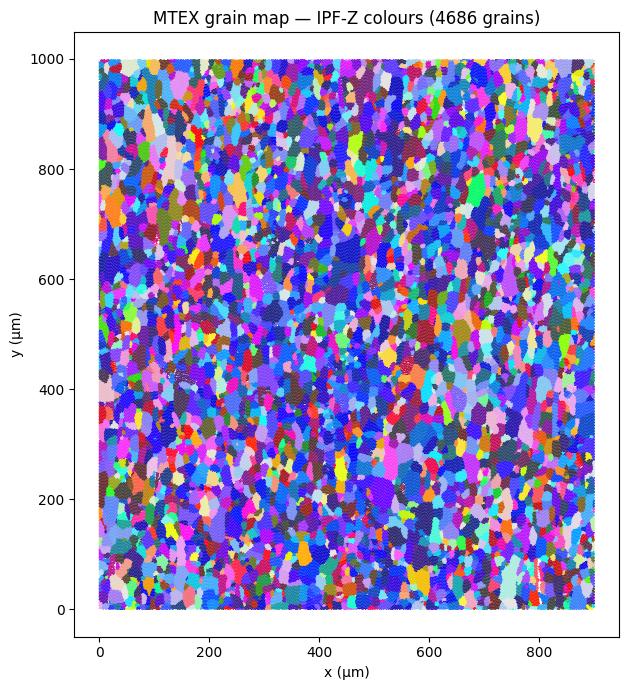

In [5]:
# Colour each pixel by its grain's IPF-Z colour
pixel_colors = coloring[grain_ids.numpy()]  # (M, 3)

step = 3
sl = slice(None, None, step)

fig, ax = plt.subplots(figsize=(8, 7))
ax.scatter(gm[sl, 0], gm[sl, 1], c=pixel_colors[sl], s=0.9, linewidths=0, rasterized=True)
ax.set_aspect('equal')
ax.set_xlabel('x (\u03bcm)'); ax.set_ylabel('y (\u03bcm)')
ax.set_title(f'MTEX grain map \u2014 IPF-Z colours ({N_grains} grains)')
plt.tight_layout()
plt.show()

The grain structure is now clearly visible: each colour corresponds to one grain with a uniform mean orientation.

---
## 4. Fit an APD to the EBSD grain geometry

`min_diagram_system` takes the MTEX pixel positions and grain map directly.
`apd_from_grain_map()` extracts per-grain centroids and ellipse parameters from the pixel data
and returns a heuristic `apd_system` ready to plot or optimise.

In [6]:
pixel_params = (300, 300)

mds = min_diagram_system(
    Y=Y_um_mtex,
    grain_map=grain_ids,
    pixel_params=pixel_params,
    ho=2,
    basis=Legendre,
    eps=1e-2,
    heuristic_guess=True,
    dt=torch.float32,
    device='cpu',
)

apd_i = mds.apd_from_grain_map()
apd_i.assemble_pixels()
print(f"APD: {N_grains} grains, {apd_i.Y.shape[0]} pixels")

APD: 4686 grains, 90000 pixels


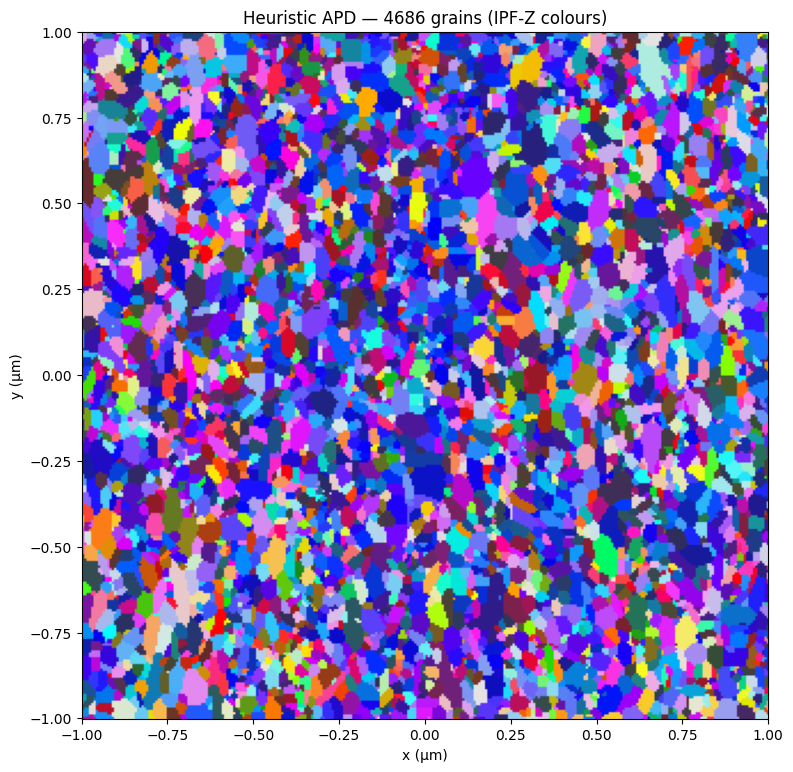

In [7]:
# Assemble and display the heuristic APD coloured by IPF-Z colours
gc  = torch.tensor(coloring, dtype=torch.float32)
img = apd_i.assemble_apd(color_by=gc)
img2 = img.reshape(pixel_params + (3,)).transpose(0, 1).cpu().numpy()  # (py, px, 3)

ratio = (apd_i.domain[0, 1] - apd_i.domain[0, 0]) / (apd_i.domain[1, 1] - apd_i.domain[1, 0])
fig, ax = plt.subplots(figsize=(ratio.item() * 8, 8))
ax.imshow(img2, origin='upper', extent=torch.flatten(apd_i.domain).tolist())
ax.set_title(f'Heuristic APD \u2014 {N_grains} grains (IPF-Z colours)')
ax.set_xlabel('x (\u03bcm)'); ax.set_ylabel('y (\u03bcm)')
plt.tight_layout()
plt.show()

In [8]:
# To run full optimisation, move to GPU:
# apd_i.find_optimal_W(verbose=True)
# (CPU is too slow for N \u2248 4000; uncomment on a GPU machine)

---
## 5. Export back to `.ang`

After fitting, export the APD as a `.ang` file for re-import into MTEX or OIM.

In [9]:
grain_map_apd = apd_i.assemble_apd()   # (M,) grain index per pixel
Y_np          = apd_i.Y.cpu().numpy()  # (M, 2) positions in \u03bcm
px_size       = (apd_i.domain[0, 1] - apd_i.domain[0, 0]).item() / pixel_params[0]

write_ang_file(
    path='/tmp/apd_heuristic.ang',
    Y=Y_np,
    euler_angles=mean_orient,
    grain_ids=grain_map_apd.cpu().numpy(),
    pixel_size=px_size,
    phase_info=[{
        'name': 'Iron', 'formula': 'Fe',
        'symmetry': 43,
        'lattice': [2.870, 2.870, 2.870, 90.0, 90.0, 90.0],
    }],
)
print('Written: /tmp/apd_heuristic.ang')

Written: /tmp/apd_heuristic.ang


The exported `.ang` can be re-imported into MTEX with `EBSD.load('apd_heuristic.ang')` for direct pixel-level comparison against the ground truth.

---
## 6. `.h5oina` format

> **Requires `h5py`** (`pip install h5py`). `.h5oina` is the Oxford Instruments HDF5 EBSD format.

`load_setup_from_h5oina` extracts pixel positions and sizes for use with `set_pixels`, and handles non-rectangular scan geometries automatically.

In [10]:
# \u26a0\ufe0f  Requires h5py and an .h5oina file
# from PyAPD.ebsd_utils import load_setup_from_h5oina
#
# data = load_setup_from_h5oina('path/to/scan.h5oina')
# print(f"Loaded {data['Y'].shape[0]} pixels, step {data['xstep']:.4f} \u00d7 {data['ystep']:.4f} \u03bcm")
#
# apd_h5 = PyAPD.apd_system(D=2, N=N_grains, dt=torch.float32)
# apd_h5.set_pixels(data['Y'], data['PS'])
# apd_h5.find_optimal_W()